# 🎓 The Math Tutor — LangGraph Edition
### Chandra OCR 2 · LangChain OpenAI · SymPy · E2B Sandbox · LangGraph
**Domains:** Civil Engineering (Beams, MoI) · Graph Theory (CSE) · **Any Math Subject** (Calculus, Algebra, Stats, …)
---
## Architecture
```
                    +---------------------------------------------------+
                    |                  HWGraderState                    |
                    |  image_input, ocr_result, parsed_problem, units, |
                    |  solver_result, critic_result, error              |
                    +---------------------------------------------------+
                                        |
  START --> [ node_ocr ] --> should_continue? --> [ node_solver ] --> [ node_critic ] --> END
                                  | (error)
                                 END
```
**Problem-Type Routing (dispatch_solver):**
| problem_type | Solver strategy |
|---|---|
| beam_reactions | Pure SymPy (analytical) — **units from parser** |
| moment_of_inertia | Pure SymPy (analytical) |
| graph_theory | Unified E2B solver (LLM code-gen → NetworkX sandbox) |
| **other** | **Unified E2B solver** (LLM code-gen → sympy/numpy/scipy sandbox) |

**Production-Grade Contracts:**
Every node returns Pydantic-validated data. `ParsedBeamReactions`, `ParsedMoI`,
`ParsedGraphTheory`, `ParsedOther` — all validated before reaching the solver.
`SolverResult`, `CriticOutput` — deterministic output schemas.

## Cell 1 — Installation
> Run once, then restart the kernel.

In [ ]:
import subprocess, sys
packages = [
    "chandra-ocr[hf]",
    "bitsandbytes>=0.43.0",
    "transformers>=4.47.0",
    "accelerate>=0.26.0",
    "langchain",
    "langchain-openai",
    "langchain-core",
    "langgraph",
    "sympy",
    "python-dotenv",
    "Pillow",
    "matplotlib",
    "numpy",
    "e2b_code_interpreter",
    "pydantic>=2.0",
]
for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
print("All packages installed. Restart kernel if this is the first run.")

## Cell 2 — Imports, Config, Pydantic Schemas & State

All LangGraph state lives in `HWGraderState`. Every node receives this dict,
updates only its own keys, and returns a partial dict. LangGraph handles merging.

**New in this version:**
- `units` field in state — parser extracts force/moment/length units from OCR
- Full Pydantic models for every node's output — deterministic, serialisable, FastAPI-ready

In [1]:
import os, json, re, math
from typing import TypedDict, Optional, Union, List, Literal, Annotated
from enum import Enum

from pydantic import BaseModel, Field, field_validator
from PIL import Image
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langgraph.graph import StateGraph, START, END
from sympy import symbols, solve, Eq

load_dotenv()   # Loads OPENAI_API_KEY from .env automatically

# ═══ Model Settings ═══════════════════════════════════════════════════════════
CHANDRA_MODEL_ID  = "datalab-to/chandra-ocr-2"
PARSER_MODEL      = "gpt-5.4-mini-2026-03-17"
CRITIC_MODEL      = "gpt-5.4-2026-03-05"
MAX_OUTPUT_TOKENS = 12384
E2B_API_KEY       = os.environ.get("E2B_API_KEY", "")

# ═══ Pydantic Schemas — Production-Grade Node Contracts ═══════════════════════

# --- OCR Result ---------------------------------------------------------------
class OCRResult(BaseModel):
    """Output of Node 1 (OCR). Deterministic shape for downstream nodes."""
    markdown   : str   = Field(description="Combined OCR markdown from all pages")
    raw_ocr    : str   = Field(description="Unprocessed OCR output")
    page_count : int   = Field(ge=1, description="Number of pages processed")
    image      : Optional[str] = Field(default=None, description="Optional image reference")


# --- Units (NEW — dynamic, parsed from OCR) -----------------------------------
class ProblemUnits(BaseModel):
    """
    Units extracted by the parser from the OCR text.
    The solver uses these instead of hardcoded 'kN' / 'kN.m' / 'm'.
    """
    force  : str = Field(default="kN",   description="Force unit, e.g. kN, N, lb, kip")
    moment : str = Field(default="kN.m", description="Moment unit, e.g. kN.m, N.m, lb.ft, kip.ft")
    length : str = Field(default="m",    description="Length unit, e.g. m, mm, ft, in")


# --- Parsed Problem — discriminated by problem_type ---------------------------

class PointLoad(BaseModel):
    type      : Literal["point"] = "point"
    magnitude : float = Field(description="Force magnitude in force-units")
    position  : float = Field(description="Distance from left support in length-units")

class UDLoad(BaseModel):
    type      : Literal["udl"] = "udl"
    magnitude : float = Field(description="Load intensity in force-units / length-unit")
    position  : float = Field(description="Start position from left support")
    length    : float = Field(description="Length of distributed load")

class UVLoad(BaseModel):
    type      : Literal["uvl"] = "uvl"
    w_start   : float = Field(description="Intensity at left end of load region")
    w_end     : float = Field(description="Intensity at right end of load region")
    position  : float = Field(description="Start position from left support")
    length    : float = Field(description="Length of load region")

class MomentLoad(BaseModel):
    type      : Literal["moment"] = "moment"
    magnitude : float = Field(description="Moment magnitude in moment-units")
    position  : float = Field(description="Position from left support")
    direction : Literal["clockwise", "anticlockwise"] = "clockwise"

class ParsedBeamReactions(BaseModel):
    problem_type : Literal["beam_reactions"] = "beam_reactions"
    support_type : Literal["simply_supported", "cantilever"]
    span         : float = Field(gt=0, description="Total span in length-units")
    loads        : List[Union[PointLoad, UDLoad, UVLoad, MomentLoad]]
    units        : ProblemUnits = Field(default_factory=ProblemUnits)

class ParsedMomentOfInertia(BaseModel):
    problem_type : Literal["moment_of_inertia"] = "moment_of_inertia"
    section_type : Literal["rectangle", "circle", "hollow_circle", "I_section"]
    dimensions   : dict  = Field(description="Section dimensions in mm")
    units        : ProblemUnits = Field(default_factory=lambda: ProblemUnits(force="N", moment="N.mm", length="mm"))

class ParsedGraphTheory(BaseModel):
    problem_type      : Literal["graph_theory"] = "graph_theory"
    graph_description : str = Field(description="Graph structure: directed/undirected, vertices, edges, weights")
    question          : str = Field(description="What must be solved or verified")
    student_claim     : str = Field(default="", description="Student's claimed answer from OCR")

class ParsedOther(BaseModel):
    problem_type  : Literal["other"] = "other"
    subject       : str = Field(description="Math subject area, e.g. calculus, linear_algebra, statistics")
    question      : str = Field(description="The problem statement to solve")
    student_claim : str = Field(default="", description="Student's claimed answer from OCR")

# Union type for the dispatcher
ParsedProblem = Union[ParsedBeamReactions, ParsedMomentOfInertia, ParsedGraphTheory, ParsedOther]


# --- Solver Result ------------------------------------------------------------
class SolverResult(BaseModel):
    """Deterministic output contract for every solver path."""
    solution_steps   : str            = Field(description="Human-readable step-by-step solution")
    generated_code   : Optional[str]  = Field(default=None, description="Python code (E2B solvers only)")
    execution_result : Optional[str]  = Field(default=None, description="E2B stdout (E2B solvers only)")
    numeric_results  : Optional[dict] = Field(default=None, description="Key numeric answers, e.g. RA, RB, Ixx")
    sfd              : Optional[dict] = Field(default=None, description="Shear force diagram data")
    bmd              : Optional[dict] = Field(default=None, description="Bending moment diagram data")


# --- Critic Output (unchanged from original, already Pydantic) ----------------
class CriticOutput(BaseModel):
    """Structured grading output from the Math Tutor critic."""
    grade: Literal["Pass", "Fail"] = Field(
        description="Pass if the student's solution is fully correct, Fail if any error is found."
    )
    error_line: str = Field(
        description="The specific step/line number where the FIRST error occurs, e.g. 'Step 3'. Write 'None' if no error."
    )
    error_location_detail: str = Field(
        default="None",
        description=(
            "A precise, quotable description of exactly WHERE in the student's handwritten work "
            "the error appears — so a teacher can locate it on the physical paper. "
            "Include: the step/line reference AND the exact expression the student wrote. "
            "Write 'None' if grade is Pass."
        )
    )
    error_type: Literal["Arithmetic", "Conceptual", "Formula", "Sign Error", "Units", "None"] = Field(
        description="Category of the error found. Use 'None' if grade is Pass."
    )
    explanation: str = Field(
        description="2-4 sentences explaining what the student did wrong and why it is incorrect."
    )
    correct_step: str = Field(
        description="The correct version of the erroneous line. Write 'N/A' if grade is Pass."
    )
    additional_notes: str = Field(
        default="None",
        description="Any other observations about the student's approach, or 'None'."
    )


# ═══ LangGraph State ═════════════════════════════════════════════════════════
class HWGraderState(TypedDict):
    image_input    : Union[str, List[str], List]          # single path, list of paths, or PIL Images
    ocr_result     : Optional[dict]                       # OCRResult.model_dump()
    parsed_problem : Optional[dict]                       # ParsedProblem.model_dump()
    units          : Optional[dict]                       # ProblemUnits.model_dump()  ← NEW
    solver_result  : Optional[dict]                       # SolverResult.model_dump()
    critic_result  : Optional[dict]                       # CriticOutput fields + raw object
    error          : Optional[str]


print("Config loaded.")
print(f"   Parser model   : {PARSER_MODEL}")
print(f"   Critic model   : {CRITIC_MODEL}")
print(f"   OpenAI API key : {'found' if os.environ.get('OPENAI_API_KEY') else 'NOT FOUND'}")
print(f"   E2B API key    : {'found' if os.environ.get('E2B_API_KEY') else 'NOT SET'}")
print(f"   Chandra API key: {'found' if os.environ.get('CHANDRA_API_KEY') else 'NOT FOUND'}")
print()
print("Pydantic schemas registered:")
for cls in [OCRResult, ProblemUnits, ParsedBeamReactions, ParsedMomentOfInertia,
            ParsedGraphTheory, ParsedOther, SolverResult, CriticOutput]:
    print(f"   ✓ {cls.__name__}")

e:\Artifical Intelligence Learning Journey\LangGraph\OCR_langGraph_openai_math\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Config loaded.
   Parser model   : gpt-5.4-mini-2026-03-17
   Critic model   : gpt-5.4-2026-03-05
   OpenAI API key : found
   E2B API key    : found
   Chandra API key: found

Pydantic schemas registered:
   ✓ OCRResult
   ✓ ProblemUnits
   ✓ ParsedBeamReactions
   ✓ ParsedMomentOfInertia
   ✓ ParsedGraphTheory
   ✓ ParsedOther
   ✓ SolverResult
   ✓ CriticOutput


---
## Cell 3 — Node 1: Chandra OCR 2 (API + node function)

The hosted API is used for accuracy. Output is validated through `OCRResult`.

In [2]:
import requests, time, os
from PIL import Image

CHANDRA_API_URL    = "https://www.datalab.to/api/v1/convert"
POLL_INTERVAL_SECS = 2
MAX_POLL_ATTEMPTS  = 60   # 2 minutes max wait

CHANDRA_API_KEY = os.environ.get("CHANDRA_API_KEY", "")

if not CHANDRA_API_KEY:
    print("WARNING: CHANDRA_API_KEY not found in .env")
else:
    print(f"Chandra API key loaded: {CHANDRA_API_KEY[:8]}...")


def ocr_via_api(image_path: str) -> str:
    """
    Submit one image to Chandra hosted API, poll until done, return markdown.
    """
    headers = {"X-API-Key": CHANDRA_API_KEY}

    with open(image_path, "rb") as f:
        response = requests.post(
            CHANDRA_API_URL,
            headers=headers,
            files={"file": (os.path.basename(image_path), f, "image/jpeg")},
            data={"output_format": "markdown", "mode": "balanced"},
        )

    if response.status_code != 200:
        raise RuntimeError(
            f"Chandra API returned {response.status_code}: {response.text[:200]}"
        )

    job = response.json()
    if not job.get("success"):
        raise RuntimeError(f"Submission failed: {job.get('error')}")

    check_url = job["request_check_url"]
    print(f"   Job submitted. Polling for result...")

    for attempt in range(MAX_POLL_ATTEMPTS):
        time.sleep(POLL_INTERVAL_SECS)
        result  = requests.get(check_url, headers=headers).json()
        status  = result.get("status", "")
        print(f"   Attempt {attempt+1}: {status}")

        if status == "complete":
            return result.get("markdown", "")
        elif status == "error":
            raise RuntimeError(f"API processing error: {result.get('error')}")

    raise TimeoutError("Chandra API did not complete within the timeout window.")

Chandra API key loaded: VQKSn2EG...


In [3]:
def node_ocr(state: HWGraderState) -> dict:
    """
    LangGraph Node 1 — OCR via Chandra hosted API.

    Reads  : state['image_input']
    Writes : state['ocr_result'] (validated OCRResult)  OR state['error']
    """
    print("\n[Node 1/3] OCR — Chandra hosted API...")

    try:
        img_input = state["image_input"]
        inputs    = [img_input] if isinstance(img_input, (str, Image.Image)) else img_input

        all_markdown = []

        for i, item in enumerate(inputs):
            print(f"   Page {i+1}/{len(inputs)}...")

            if isinstance(item, Image.Image):
                tmp_path = f"_tmp_ocr_page_{i}.jpg"
                item.save(tmp_path, "JPEG")
                path = tmp_path
            else:
                path = item

            page_markdown = ocr_via_api(path)

            all_markdown.append(
                f"--- PAGE {i+1} ---\n{page_markdown}"
                if len(inputs) > 1
                else page_markdown
            )

        combined = "\n\n".join(all_markdown)

        print(f"OCR complete — {len(inputs)} page(s), {len(combined)} chars")
        print("-" * 55)
        print(combined[:600] + ("..." if len(combined) > 600 else ""))
        print("-" * 55)

        # Validate through Pydantic before returning
        ocr_out = OCRResult(
            markdown   = combined,
            raw_ocr    = combined,
            page_count = len(inputs),
            image      = None,
        )

        return {"ocr_result": ocr_out.model_dump()}

    except Exception as e:
        return {"error": f"[Node 1 OCR] {type(e).__name__}: {e}"}


print("node_ocr (Chandra API) ready.")

node_ocr (Chandra API) ready.


---
## Cell 4 — Node 2: Universal Parser + Solver

**Parser changes (v2):**
- Prompt is **domain-agnostic** — detects beam reactions, MoI, graph theory, OR any other math subject
- Extracts **units** from OCR text (force, moment, length) → stored in `state['units']`
- Returns Pydantic-validated `ParsedProblem` (discriminated union)

**Solver changes (v2):**
- **Unified E2B solver** — `graph_theory` and `other` share the same code-gen + sandbox path
- Beam/MoI solvers use **dynamic units** from the parser instead of hardcoded kN/m

In [4]:
# ═══ 2a: Universal Problem Parser (LangChain) ════════════════════════════════
_parser_chain = None
print("Parser chain cache cleared — will rebuild on next call.")


def get_parser_chain():
    global _parser_chain
    if _parser_chain is not None:
        return _parser_chain

    llm = ChatOpenAI(
        model=PARSER_MODEL,
        max_tokens=1000,
        model_kwargs={"response_format": {"type": "json_object"}},
    )

    # ── UNIVERSAL system prompt — not civil-engineering-only ──────────────
    SYSTEM_PROMPT = """\
You are a UNIVERSAL math / science problem parser.
Your job: read OCR text from handwritten student homework and extract structured
parameters so a downstream solver can compute the correct answer.

Return ONLY valid JSON — no explanation, no markdown fences.

─── STEP 1: IDENTIFY THE PROBLEM TYPE ───

Read the OCR text and classify it into ONE of these categories:

  "beam_reactions"     — beam with supports, spans, point/distributed loads, moments
  "moment_of_inertia"  — cross-section geometry (rectangle, circle, I-section, etc.)
  "graph_theory"       — vertices, edges, paths, cycles, trees, BFS, DFS, shortest path, MST
  "other"              — ANY other math/science subject (calculus, algebra, statistics,
                         linear algebra, differential equations, probability, physics, etc.)

─── STEP 2: IDENTIFY UNITS ───

Look for unit indicators in the OCR text. Return a "units" object:
{{
  "units": {{
    "force" : "<force unit found, e.g. kN, N, lb, kip — default kN>",
    "moment": "<moment unit found, e.g. kN.m, N.m, lb.ft — default kN.m>",
    "length": "<length unit found, e.g. m, mm, ft, in — default m>"
  }}
}}

Unit detection rules:
- If the problem says "10 kN" → force="kN"
- If the problem says "5 N/m" → force="N", length="m"
- If the problem says "20 lb" or "20 lbs" → force="lb"
- If the problem says "span = 8 ft" → length="ft"
- Derive moment unit from force × length (e.g. force="kN" + length="m" → moment="kN.m")
- If no units are visible, use defaults: force="kN", moment="kN.m", length="m"

─── STEP 3: RETURN TYPE-SPECIFIC JSON ───

For BEAM REACTIONS return:
{{
  "problem_type": "beam_reactions",
  "support_type": "simply_supported" | "cantilever",
  "span": <total span, number>,
  "loads": [
    {{"type": "point", "magnitude": <force-units>, "position": <length-units from left>}},
    {{"type": "udl", "magnitude": <force/length>, "position": <start>, "length": <length>}},
    {{"type": "uvl", "w_start": <intensity at left>, "w_end": <intensity at right>, "position": <start>, "length": <length>}},
    {{"type": "moment", "magnitude": <moment-units>, "position": <from left>, "direction": "clockwise" | "anticlockwise"}}
  ],
  "units": {{ ... }}
}}

Load type rules:
- "point"  : concentrated force, always downward
- "udl"    : uniform load over a length, "magnitude" is intensity (force/length)
- "uvl"    : linearly varying — w_start=0 for zero-to-max triangle, w_end=0 for max-to-zero
- "moment" : applied couple — direction must be "clockwise" or "anticlockwise"

Support type rules:
- "simply_supported" : hinge (pin) at A, roller at B
- "cantilever"       : fixed wall at A, free end at B

For MOMENT OF INERTIA return:
{{
  "problem_type": "moment_of_inertia",
  "section_type": "rectangle" | "circle" | "hollow_circle" | "I_section",
  "dimensions": {{
    "b": <mm>, "h": <mm>,
    "d": <mm>,
    "D": <mm>,
    "bf": <mm>, "tf": <mm>, "hw": <mm>, "tw": <mm>
  }},
  "units": {{ "force": "N", "moment": "N.mm", "length": "mm" }}
}}

For GRAPH THEORY (CSE / discrete-math) return:
{{
  "problem_type"     : "graph_theory",
  "graph_description": "<directed/undirected/weighted, vertices, edges, weights>",
  "question"         : "<what must be solved or verified>",
  "student_claim"    : "<student answer from OCR, empty string if not visible>"
}}
Graph theory keywords: vertex, node, edge, path, cycle, tree, BFS, DFS,
  shortest path, spanning tree, connectivity, degree, adjacency, MST.

For ANY OTHER MATH SUBJECT return:
{{
  "problem_type"  : "other",
  "subject"       : "<calculus | algebra | linear_algebra | statistics | probability | trigonometry | differential_equations | physics | ...>",
  "question"      : "<precise problem statement extracted from OCR>",
  "student_claim" : "<student's final answer from OCR, empty string if not visible>"
}}

If values are missing, make a reasonable assumption based on context."""

    prompt = ChatPromptTemplate.from_messages([
        ("system", SYSTEM_PROMPT),
        ("user", "Parse the following handwritten problem from OCR:\n\n{ocr_text}\n\nReturn JSON only."),
    ])
    _parser_chain = prompt | llm
    return _parser_chain


def parse_problem_from_ocr(ocr_text: str) -> tuple:
    """
    Run the universal parser chain.
    Returns (ParsedProblem, ProblemUnits) — both Pydantic-validated.
    """
    chain    = get_parser_chain()
    response = chain.invoke({"ocr_text": ocr_text})
    raw      = response.content.strip()
    raw      = re.sub(r"^```[a-z]*\n?|```$", "", raw, flags=re.MULTILINE).strip()

    try:
        params = json.loads(raw)
    except json.JSONDecodeError as e:
        raise ValueError(f"Parser returned invalid JSON:\n{raw}\n\nError: {e}")

    # ── Extract and validate units ────────────────────────────────────────
    raw_units = params.pop("units", {})
    units = ProblemUnits(**raw_units) if raw_units else ProblemUnits()

    # ── Validate parsed problem through Pydantic ──────────────────────────
    ptype = params.get("problem_type", "other")

    VALIDATORS = {
        "beam_reactions"    : ParsedBeamReactions,
        "moment_of_inertia" : ParsedMomentOfInertia,
        "graph_theory"      : ParsedGraphTheory,
        "other"             : ParsedOther,
    }

    ValidatorCls = VALIDATORS.get(ptype)
    if ValidatorCls is None:
        raise ValueError(f"Unknown problem_type '{ptype}' — expected one of {list(VALIDATORS)}")

    # For beam_reactions, inject units into model (it has a units field)
    if ptype == "beam_reactions":
        params["units"] = units.model_dump()

    validated = ValidatorCls(**params)

    # ── Console summary ───────────────────────────────────────────────────
    print(f"   Problem type : {ptype}")
    print(f"   Units        : force={units.force}, moment={units.moment}, length={units.length}")

    if ptype == "beam_reactions":
        print(f"   Support type : {validated.support_type}")
        print(f"   Span         : {validated.span} {units.length}")
        print(f"   Loads found  : {len(validated.loads)}")
        for i, l in enumerate(validated.loads):
            print(f"     Load {i+1}: {l.type} — {l.model_dump()}")
    elif ptype == "moment_of_inertia":
        print(f"   Section type : {validated.section_type}")
        print(f"   Dimensions   : {validated.dimensions}")
    elif ptype == "graph_theory":
        print(f"   Question     : {validated.question[:100]}")
        print(f"   Student claim: {validated.student_claim[:80]}")
    elif ptype == "other":
        print(f"   Subject      : {validated.subject}")
        print(f"   Question     : {validated.question[:100]}")
        print(f"   Student claim: {validated.student_claim[:80]}")

    return validated, units

Parser chain cache cleared — will rebuild on next call.


In [5]:
# ═══ 2b: SymPy Beam Reactions Solver + SFD + BMD (dynamic units) ═════════════

import numpy as np
from sympy import symbols, solve, Eq


def _shear_at(x, ra, loads):
    """Shear force at position x, accumulating from left support."""
    V = ra
    for load in loads:
        ld = load if isinstance(load, dict) else load.model_dump()
        ltype = ld["type"]
        if ltype == "point":
            if x > ld["position"]:
                V -= ld["magnitude"]
        elif ltype == "udl":
            x0, L, w = ld["position"], ld["length"], ld["magnitude"]
            if x > x0:
                V -= w * min(x - x0, L)
        elif ltype == "uvl":
            x0      = ld["position"]
            L       = ld["length"]
            w_start = ld.get("w_start", 0.0)
            w_end   = ld.get("w_end",   0.0)
            if x > x0:
                s = min(x - x0, L)
                V -= w_start * s + (w_end - w_start) * s**2 / (2 * L)
    return V


def _moment_at(x, ra, loads):
    """Bending moment at position x, accumulating from left support."""
    M = ra * x
    for load in loads:
        ld = load if isinstance(load, dict) else load.model_dump()
        ltype = ld["type"]
        if ltype == "point":
            a = ld["position"]
            if x > a:
                M -= ld["magnitude"] * (x - a)
        elif ltype == "udl":
            x0, L, w = ld["position"], ld["length"], ld["magnitude"]
            if x > x0:
                s = min(x - x0, L)
                M -= w * s * (x - x0 - s / 2)
        elif ltype == "uvl":
            x0      = ld["position"]
            L       = ld["length"]
            w_start = ld.get("w_start", 0.0)
            w_end   = ld.get("w_end",   0.0)
            if x > x0:
                s    = min(x - x0, L)
                xrel = x - x0
                M   -= (w_start * s * (xrel - s / 2)
                        + (w_end - w_start) / L
                        * (s**2 / 2 * xrel - s**3 / 3))
        elif ltype == "moment":
            a         = ld["position"]
            direction = ld.get("direction", "clockwise").lower()
            mag       = ld["magnitude"]
            if x > a:
                M -= mag if direction == "clockwise" else -mag
    return M


def _find_zero_shear(ra, loads, span):
    xs = np.linspace(0, span, 5000)
    Vs = np.array([_shear_at(float(xi), ra, loads) for xi in xs])
    crossings = []
    for k in range(len(Vs) - 1):
        if Vs[k] * Vs[k+1] < 0:
            lo, hi = float(xs[k]), float(xs[k+1])
            for _ in range(50):
                mid = (lo + hi) / 2
                if _shear_at(mid, ra, loads) * _shear_at(lo, ra, loads) < 0:
                    hi = mid
                else:
                    lo = mid
            crossings.append((lo + hi) / 2)
    return crossings


def solve_beam_reactions(params, units: ProblemUnits = None) -> SolverResult:
    """
    Solve beam reactions with DYNAMIC UNITS from the parser.
    All output text uses the actual units instead of hardcoded kN/m.
    """
    if units is None:
        units = ProblemUnits()

    fu = units.force          # e.g. "kN"
    mu = units.moment         # e.g. "kN.m"
    lu = units.length         # e.g. "m"
    flu = f"{fu}/{lu}"        # e.g. "kN/m"

    RA_sym, RB_sym = symbols('RA RB', real=True)

    # Handle both Pydantic model and raw dict
    if isinstance(params, BaseModel):
        span  = float(params.span)
        loads = [l.model_dump() for l in params.loads]
        stype = params.support_type
    else:
        span  = float(params["span"])
        loads = params["loads"]
        stype = params.get("support_type", "simply_supported")

    steps = []
    steps += [
        "=" * 60,
        "  BEAM REACTIONS + SFD + BMD  —  CORRECT SOLUTION",
        "=" * 60,
        f"  Span         : {span} {lu}",
        f"  Support type : {stype.replace('_', ' ').title()}",
        f"  Units        : force={fu}, moment={mu}, length={lu}",
        "",
        "  SIGN CONVENTION:",
        "    Vertical forces  — Upward = positive",
        "    Moments          — Anti-clockwise (ACW) = positive",
        "    Shear force      — Upward forces to LEFT of section = positive",
        "    Bending moment   — Sagging = positive (tension at bottom)",
        "",
    ]

    # ── STEP 1: Identify and resolve all loads ───────────────
    steps += [
        "=" * 60,
        "STEP 1 — IDENTIFY & RESOLVE ALL LOADS",
        "=" * 60, "",
    ]

    total_vert = 0.0
    mom_A      = 0.0

    for i, load in enumerate(loads):
        ltype = load["type"]
        steps.append(f"  --- Load {i+1} ---")

        if ltype == "point":
            F = float(load["magnitude"])
            x = float(load["position"])
            total_vert += F
            mom_A      += F * x
            steps += [
                f"  Type     : Concentrated Point Load",
                f"  Magnitude: F = {F} {fu} (downward)",
                f"  Position : x = {x} {lu} from A",
                f"  Contribution to ΣFy : +{F} {fu}",
                f"  Moment about A      : {F} × {x} = {F*x} {mu} (ACW)",
                "",
            ]

        elif ltype == "udl":
            w   = float(load["magnitude"])
            x0  = float(load["position"])
            L   = float(load["length"])
            Feq = w * L
            xeq = x0 + L / 2
            total_vert += Feq
            mom_A      += Feq * xeq
            steps += [
                f"  Type     : Uniformly Distributed Load (UDL)",
                f"  Intensity: w = {w} {flu}",
                f"  Extent   : x = {x0} {lu}  to  x = {x0+L} {lu}  (length = {L} {lu})",
                f"  Equivalent point load = w × L = {w} × {L} = {Feq} {fu}",
                f"  Centroid from A       = {x0} + L/2 = {xeq} {lu}",
                f"  Moment about A        : {Feq} × {xeq} = {round(Feq*xeq, 4)} {mu} (ACW)",
                "",
            ]

        elif ltype == "uvl":
            w_start = float(load.get("w_start", 0.0))
            w_end   = float(load.get("w_end",   0.0))
            x0      = float(load["position"])
            L       = float(load["length"])
            Feq     = 0.5 * (w_start + w_end) * L
            xc      = (L * (2 * w_end + w_start) / (3 * (w_start + w_end))
                       if (w_start + w_end) > 0 else L / 2)
            xeq     = x0 + xc
            total_vert += Feq
            mom_A      += Feq * xeq
            steps += [
                f"  Type     : Uniformly Varying Load (UVL)",
                f"  Intensity: {w_start} {flu} at x={x0} {lu}  →  {w_end} {flu} at x={x0+L} {lu}",
                f"  Extent   : length = {L} {lu}",
                f"  Feq = 0.5 × ({w_start} + {w_end}) × {L} = {Feq} {fu}",
                f"  Centroid from x0 = {round(xc, 4)} {lu}  →  x = {round(xeq,4)} {lu} from A",
                f"  Moment about A   : {Feq} × {round(xeq,4)} = {round(Feq*xeq,4)} {mu} (ACW)",
                "",
            ]

        elif ltype == "moment":
            M_val = float(load["magnitude"])
            x     = float(load["position"])
            dir_  = load.get("direction", "clockwise").lower()
            if dir_ == "clockwise":
                mom_A -= M_val
                steps += [
                    f"  Type     : Applied External Moment",
                    f"  Magnitude: M = {M_val} {mu}",
                    f"  Direction: CLOCKWISE (CW) — negative in ACW convention",
                    f"  Contribution to ΣMA : -{M_val} {mu}",
                    "",
                ]
            else:
                mom_A += M_val
                steps += [
                    f"  Type     : Applied External Moment",
                    f"  Magnitude: M = {M_val} {mu}",
                    f"  Direction: ANTI-CLOCKWISE (ACW) — positive",
                    f"  Contribution to ΣMA : +{M_val} {mu}",
                    "",
                ]

    steps += [
        "-" * 60,
        f"  ΣFy = {total_vert} {fu}",
        f"  ΣMA = {round(mom_A, 4)} {mu}",
        "",
    ]

    # ── STEP 2 + 3: Equilibrium ──────────────────────────────
    if stype == "simply_supported":
        steps += [
            "=" * 60, "STEP 2 — EQUILIBRIUM EQUATIONS", "=" * 60,
            f"  ΣFy = 0:   RA + RB = {total_vert}   ... (Eq 1)",
            f"  ΣMA = 0:   RB × {span} = {round(mom_A, 4)}   ... (Eq 2)",
            "",
        ]

        sol    = solve([Eq(RA_sym + RB_sym, total_vert),
                        Eq(RB_sym * span, mom_A)], [RA_sym, RB_sym])
        ra, rb = float(sol[RA_sym]), float(sol[RB_sym])

        steps += [
            "=" * 60, "STEP 3 — SOLVE", "=" * 60,
            f"  RB = {round(mom_A, 4)} / {span} = {rb:.4f} {fu}",
            f"  RA = {total_vert} - {rb:.4f} = {ra:.4f} {fu}",
            "",
            "=" * 60, "STEP 4 — VERIFICATION", "=" * 60,
            f"  RA + RB = {ra:.4f} + {rb:.4f} = {round(ra+rb, 4)} {fu}",
            f"  Total load = {total_vert} {fu}  →  {'OK' if abs(ra+rb-total_vert)<0.01 else 'ERROR'}",
            f"  RB × L = {rb:.4f} × {span} = {round(rb*span, 4)} {mu}",
            f"  ΣMA    = {round(mom_A, 4)} {mu}  →  {'OK' if abs(rb*span-mom_A)<0.01 else 'ERROR'}",
            "",
        ]

    elif stype == "cantilever":
        ra = total_vert
        rb = 0.0
        steps += [
            "=" * 60, "STEP 2 — EQUILIBRIUM (CANTILEVER)", "=" * 60,
            f"  RA = {ra:.4f} {fu}",
            f"  MA_fix = {round(mom_A,4)} {mu}",
            "",
        ]
    else:
        raise ValueError(f"Unknown support_type: '{stype}'")

    # ── STEP 5: SFD ──────────────────────────────────────────
    steps += [
        "=" * 60, "STEP 5 — SHEAR FORCE DIAGRAM (SFD)", "=" * 60, "",
    ]

    key_xs = sorted(set(
        [0.0, span] +
        [float(l["position"]) for l in loads] +
        [float(l["position"]) + float(l.get("length", 0))
         for l in loads if "length" in l]
    ))

    steps.append(f"  {'x ('+lu+')':<12} {'V(x) '+fu:<16} {'Shape between points'}")
    steps.append("  " + "-" * 55)

    for idx, x in enumerate(key_xs):
        V_before = _shear_at(x - 1e-9, ra, loads) if x > 0 else ra
        V_after  = _shear_at(x + 1e-9, ra, loads)

        if x == 0:
            steps.append(f"  {x:<12.3f} {V_after:<16.4f} START: V = RA = {ra:.4f} {fu}")
        elif x == span:
            steps.append(f"  {x:<12.3f} {V_before:<16.4f} END")
            steps.append(f"  {'':12} {'After RB:':<16} {V_before + rb:.4f} {fu}  "
                         f"{'(closes correctly)' if abs(V_before+rb) < 0.01 else '(check error)'}")
        else:
            if abs(V_after - V_before) > 0.01:
                drop = V_after - V_before
                cause = next((f"Point load {l['magnitude']}{fu}" for l in loads
                              if l["type"] == "point" and abs(float(l["position"]) - x) < 1e-6), "discontinuity")
                steps.append(f"  {x:<12.3f} {V_before:<16.4f} Just LEFT  of x={x}{lu}")
                steps.append(f"  {x:<12.3f} {V_after:<16.4f} Just RIGHT (Δ = {drop:.4f} {fu} — {cause})")
            else:
                steps.append(f"  {x:<12.3f} {V_after:<16.4f}")

    zero_crossings = _find_zero_shear(ra, loads, span)
    steps.append("")
    if zero_crossings:
        steps.append("  Zero shear crossing(s):")
        for zx in zero_crossings:
            steps.append(f"    x = {zx:.4f} {lu}")
    else:
        steps.append("  No zero shear crossing within span.")

    xs_plot = np.linspace(0, span, 300)
    Vs_plot = [_shear_at(float(x), ra, loads) for x in xs_plot]
    max_sf  = max(abs(v) for v in Vs_plot)
    steps  += ["", f"  Max shear force = {max_sf:.4f} {fu}", ""]

    # ── STEP 6: BMD ──────────────────────────────────────────
    steps += [
        "=" * 60, "STEP 6 — BENDING MOMENT DIAGRAM (BMD)", "=" * 60, "",
    ]

    steps.append(f"  {'x ('+lu+')':<12} {'M(x) '+mu:<16} {'Notes'}")
    steps.append("  " + "-" * 55)

    for x in key_xs:
        M_before = _moment_at(x - 1e-9, ra, loads)
        M_after  = _moment_at(x + 1e-9, ra, loads)
        M_val    = _moment_at(x, ra, loads)

        note = ""
        if x == 0:
            note = "M = 0 (hinge)"
        elif x == span:
            note = f"M = {M_val:.4f} {mu} ({'OK' if abs(M_val)<0.05 else 'CHECK'})"

        if abs(M_after - M_before) > 0.01 and x not in (0.0, span):
            steps.append(f"  {x:<12.3f} {M_before:<16.4f} Just LEFT")
            steps.append(f"  {x:<12.3f} {M_after:<16.4f} Just RIGHT (step = {M_after-M_before:.4f} {mu})")
        else:
            steps.append(f"  {x:<12.3f} {M_val:<16.4f} {note}")

    xs_bm  = np.linspace(0, span, 2000)
    Ms_bm  = [_moment_at(float(x), ra, loads) for x in xs_bm]
    max_bm = max(Ms_bm, key=abs)
    max_x  = float(xs_bm[Ms_bm.index(max_bm)])

    steps += [
        "",
        f"  Max bending moment = {max_bm:.4f} {mu}  at x = {max_x:.4f} {lu}",
        "",
        "=" * 60, "  FINAL RESULTS", "=" * 60,
        f"  RA     = {ra:.3f} {fu}",
    ]
    numeric = {"RA": ra}
    if stype == "simply_supported":
        steps.append(f"  RB     = {rb:.3f} {fu}")
        numeric["RB"] = rb
    else:
        steps.append(f"  MA_fix = {mom_A:.3f} {mu}")
        numeric["MA"] = mom_A
    steps += [
        f"  Vmax   = {max_sf:.3f} {fu}",
        f"  Mmax   = {abs(max_bm):.3f} {mu}  at x = {max_x:.3f} {lu}",
        "=" * 60,
    ]

    return SolverResult(
        solution_steps   = "\n".join(steps),
        numeric_results  = numeric,
        sfd              = {"x": [float(v) for v in xs_plot], "V": Vs_plot},
        bmd              = {"x": [float(v) for v in xs_bm],   "M": Ms_bm},
    )

In [6]:
# ═══ 2c: Moment of Inertia Solver ════════════════════════════════════════════
def solve_moment_of_inertia(params) -> SolverResult:
    if isinstance(params, BaseModel):
        section = params.section_type
        dims    = params.dimensions
    else:
        section = params["section_type"]
        dims    = params["dimensions"]

    steps   = ["=" * 56, "  MOMENT OF INERTIA — CORRECT SOLUTION", "=" * 56]
    res     = {}

    if section == "rectangle":
        b, h = float(dims["b"]), float(dims["h"])
        Ixx  = (b * h**3) / 12
        Iyy  = (h * b**3) / 12
        steps += [f"  Section: Rectangle  b={b}mm  h={h}mm", "",
                  "STEP 1 — Ixx = b·h³ / 12", "-" * 40,
                  f"  Ixx = {b} × {h}³ / 12 = {Ixx:,.2f} mm⁴", "",
                  "STEP 2 — Iyy = h·b³ / 12", "-" * 40,
                  f"  Iyy = {Iyy:,.2f} mm⁴",
                  "", "RESULT", "=" * 56,
                  f"  Ixx = {Ixx:,.2f} mm⁴",
                  f"  Iyy = {Iyy:,.2f} mm⁴"]
        res = {"Ixx": Ixx, "Iyy": Iyy}

    elif section == "circle":
        d = float(dims["d"])
        I = math.pi * d**4 / 64
        steps += [f"  Section: Solid Circle  d={d}mm", "",
                  f"  I = π·d⁴/64 = {I:,.4f} mm⁴",
                  "", "RESULT", "=" * 56,
                  f"  I = {I:,.4f} mm⁴"]
        res = {"I": I}

    elif section == "hollow_circle":
        D, d = float(dims["D"]), float(dims["d"])
        if d >= D:
            raise ValueError("Inner diameter d must be less than outer D")
        I = math.pi * (D**4 - d**4) / 64
        steps += [f"  Section: Hollow Circle  D={D}mm  d={d}mm", "",
                  f"  I = π(D⁴ - d⁴)/64 = {I:,.4f} mm⁴",
                  "", "RESULT", "=" * 56,
                  f"  I = {I:,.4f} mm⁴"]
        res = {"I": I}

    elif section == "I_section":
        bf, tf = float(dims["bf"]), float(dims["tf"])
        hw, tw = float(dims["hw"]), float(dims["tw"])
        H       = hw + 2 * tf
        vw      = (bf - tw) / 2
        I_gross = (bf * H**3) / 12
        I_voids = 2 * (vw * hw**3) / 12
        Ixx     = I_gross - I_voids
        steps += [f"  Section: I-Section  bf={bf} tf={tf} hw={hw} tw={tw} (mm)",
                  f"  H = {H} mm", "",
                  "STEP 1 — Subtraction method", "-" * 40,
                  f"  I_gross = {I_gross:,.2f} mm⁴",
                  f"  I_voids = {I_voids:,.2f} mm⁴",
                  f"  Ixx = {I_gross:,.2f} - {I_voids:,.2f} = {Ixx:,.2f} mm⁴",
                  "", "RESULT", "=" * 56,
                  f"  Ixx = {Ixx:,.2f} mm⁴"]
        res = {"Ixx": Ixx}
    else:
        raise ValueError(f"Unknown section_type: {section}")

    return SolverResult(
        solution_steps  = "\n".join(steps),
        numeric_results = res,
    )

---
## Cell 4b — Unified E2B Solver (Graph Theory + General Math)

**Merged:** The previous `solve_graph_theory_with_e2b` and `solve_other_with_e2b`
are now a single `solve_with_e2b` function.

Both paths use the same pattern:
1. LLM generates Python code tailored to the problem type
2. Code runs safely inside an **E2B sandbox**
3. stdout becomes the correct solution the Critic uses

For graph theory the LLM is instructed to use NetworkX.
For everything else it picks sympy / numpy / scipy as appropriate.

**Requires** `E2B_API_KEY` in `.env`. Free tier at https://e2b.dev

In [7]:
# ═══ Unified E2B Solver (graph_theory + other) ═══════════════════════════════

import re
from e2b_code_interpreter import Sandbox

_e2b_code_chain = None


def _get_e2b_code_chain():
    """
    Single LangChain chain for ALL E2B-solved problem types.
    The prompt adapts based on {problem_type} and {extra_instructions}.
    """
    global _e2b_code_chain
    if _e2b_code_chain is not None:
        return _e2b_code_chain

    from langchain_core.prompts import ChatPromptTemplate
    llm = ChatOpenAI(model=PARSER_MODEL, max_tokens=2000)

    SYSTEM = (
        "You are an expert mathematician, computer scientist, and Python programmer.\n"
        "Given a problem extracted from handwritten student work (OCR),\n"
        "write Python code that:\n"
        "  1. Solves the problem step by step, printing EVERY intermediate result.\n"
        "  2. Uses the most appropriate library:\n"
        "     - networkx : for graph theory (BFS, DFS, shortest path, MST, etc.)\n"
        "     - sympy    : for symbolic math, calculus, algebra, ODEs, trigonometry\n"
        "     - numpy / scipy : for numerical linear algebra, statistics, root finding\n"
        "     - plain print() : for proofs, logic, or problems needing only reasoning\n"
        "  3. Prints the final answer with a CLEAR label at the end.\n"
        "  4. Mirrors the solution style a textbook would use (show working, not just answer).\n\n"
        "{extra_instructions}\n\n"
        "Return ONLY raw Python code — no markdown fences, no explanation.\n"
        "networkx, sympy, numpy, scipy are pre-installed; do NOT add pip/install lines."
    )

    USER = (
        "Problem type     : {problem_type}\n"
        "Subject area     : {subject}\n"
        "Question to solve: {question}\n\n"
        "OCR text (full student submission including their attempt):\n---\n{ocr_text}\n---\n\n"
        "Write the Python solution code now:"
    )

    prompt = ChatPromptTemplate.from_messages([
        ("system", SYSTEM),
        ("user",   USER),
    ])
    _e2b_code_chain = prompt | llm
    return _e2b_code_chain


def _strip_fences(raw: str) -> str:
    """Remove ```python / ``` markdown fences the LLM might add."""
    raw = re.sub(r'^```[a-z]*\n?', '', raw, flags=re.MULTILINE)
    raw = re.sub(r'```\s*$',       '', raw, flags=re.MULTILINE)
    return raw.strip()


def solve_with_e2b(params, ocr_text: str) -> SolverResult:
    """
    Unified E2B solver for graph_theory and other problem types.
    LLM generates Python code → E2B executes → stdout becomes solution_steps.
    Returns a validated SolverResult.
    """
    if isinstance(params, BaseModel):
        ptype = params.problem_type
        p = params.model_dump()
    else:
        ptype = params.get("problem_type", "other")
        p = params

    # ── Build type-specific context ───────────────────────────────────────
    if ptype == "graph_theory":
        subject  = "graph theory / discrete mathematics"
        question = p.get("question", "Solve the graph theory problem")
        extra    = (
            "GRAPH THEORY SPECIFIC:\n"
            "  - Import networkx as nx.\n"
            "  - Build the EXACT graph described (vertices, edges, weights).\n"
            "  - Print every intermediate result (adjacency, traversal order, etc.).\n"
            "  - Graph description: {graph_desc}"
        ).format(graph_desc=p.get("graph_description", "See OCR text"))
    else:
        subject  = p.get("subject", "general mathematics")
        question = p.get("question", "Solve the problem")
        extra    = ""

    print(f"   [E2B/{subject}] Generating Python code via LLM...")
    chain    = _get_e2b_code_chain()
    response = chain.invoke({
        "problem_type"      : ptype,
        "subject"           : subject,
        "question"          : question,
        "extra_instructions": extra,
        "ocr_text"          : ocr_text,
    })
    code = _strip_fences(response.content)
    print(f"   [E2B/{subject}] Code generated ({len(code.splitlines())} lines). Running in sandbox...")

    # ── Execute in E2B sandbox ────────────────────────────────────────────
    if not E2B_API_KEY:
        result_text = (
            "[E2B not configured]\n"
            "Set E2B_API_KEY in .env to enable sandbox execution.\n"
        )
    else:
        sbx = None
        try:
            sbx       = Sandbox.create()
            execution = sbx.run_code(code)

            stdout = "\n".join(execution.logs.stdout) if execution.logs.stdout else ""
            stderr = "\n".join(execution.logs.stderr) if execution.logs.stderr else ""

            if stdout:
                result_text = stdout
            elif stderr:
                result_text = f"[stderr output]\n{stderr}"
            else:
                result_text = "(sandbox ran with no output)"

            if stderr and stdout:
                result_text += f"\n\n[stderr warnings]\n{stderr}"

        except Exception as exc:
            result_text = f"[E2B error]  {type(exc).__name__}: {exc}"
        finally:
            if sbx is not None:
                try:
                    sbx.kill()
                except Exception:
                    pass

    print(f"   [E2B/{subject}] Solver complete.")

    lines = (
        ["=" * 60,
         f"  {subject.upper()} — CORRECT SOLUTION (E2B sandbox)",
         "=" * 60, "",
         "GENERATED PYTHON CODE", "-" * 40]
        + code.split("\n")
        + ["", "EXECUTION OUTPUT", "-" * 40]
        + result_text.split("\n")
        + ["", "=" * 60]
    )

    return SolverResult(
        solution_steps   = "\n".join(lines),
        generated_code   = code,
        execution_result = result_text,
    )


print("solve_with_e2b (unified) ready.")

solve_with_e2b (unified) ready.


In [8]:
# ═══ Dispatcher + LangGraph Node 2 ═══════════════════════════════════════════

def dispatch_solver(parsed: ParsedProblem, units: ProblemUnits, ocr_text: str = "") -> SolverResult:
    """
    Route to the correct solver based on problem_type.
    Returns a validated SolverResult in all cases.
    """
    if isinstance(parsed, BaseModel):
        ptype = parsed.problem_type
    else:
        ptype = parsed.get("problem_type", "")

    if ptype == "beam_reactions":
        return solve_beam_reactions(parsed, units=units)
    elif ptype == "moment_of_inertia":
        return solve_moment_of_inertia(parsed)
    elif ptype in ("graph_theory", "other"):
        return solve_with_e2b(parsed, ocr_text)
    else:
        raise ValueError(f"Unknown problem_type: '{ptype}'")


def node_solver(state: HWGraderState) -> dict:
    """
    LangGraph Node 2: Parser + Solver.

    Reads  : state['ocr_result']['markdown']
    Writes : state['parsed_problem'], state['units'], state['solver_result']
             OR state['error']
    """
    print("\n[Node 2/3] Solver — Parsing problem & computing solution...")
    try:
        ocr_markdown = state["ocr_result"]["markdown"]

        # 2a — Universal parser (returns Pydantic models)
        print("   2a: Universal parser → extracting problem parameters...")
        parsed, units = parse_problem_from_ocr(ocr_markdown)

        # 2b — Dispatch to solver
        ptype = parsed.problem_type
        print(f"   2b: Solver → computing correct solution ({ptype})...")
        solved = dispatch_solver(parsed, units=units, ocr_text=ocr_markdown)

        print("Solver complete.")
        print(solved.solution_steps)

        return {
            "parsed_problem": parsed.model_dump(),
            "units"         : units.model_dump(),
            "solver_result" : solved.model_dump(),
        }

    except Exception as e:
        return {"error": f"[Node 2 Solver] {type(e).__name__}: {e}"}

---
## Cell 5 — Node 3: Critic (LangChain + Pydantic Structured Output)

Compares the student's OCR work against the correct solution line by line.
Uses `CriticOutput` Pydantic model bound to the LLM via `.with_structured_output()`.

| Field | Possible Values |
|---|---|
| `grade` | Pass / Fail |
| `error_line` | e.g. "Line 3" or "None" |
| `error_type` | Arithmetic / Conceptual / Formula / Sign Error / Units / None |
| `explanation` | What went wrong and why |
| `correct_step` | What the student should have written |

In [9]:
from itertools import chain as ichain   # renamed to avoid shadowing

_critic_chain = None


def get_critic_chain():
    """
    Build and cache the critic chain using .with_structured_output().
    CriticOutput Pydantic model is already defined in Cell 2.
    """
    global _critic_chain
    if _critic_chain is not None:
        return _critic_chain

    llm = ChatOpenAI(model=CRITIC_MODEL)
    structured_llm = llm.with_structured_output(CriticOutput)

    SYSTEM_PROMPT = (
            "You are a fair and experienced {role} grading handwritten homework that was "
            "digitised by an OCR model.\n\n"

            "═══ GROUND RULES ═══\n\n"

            "RULE 1 — VERIFY NUMERICALLY, NOT VISUALLY.\n"
            "Before calling anything an error, evaluate BOTH the student's expression "
            "and the reference expression to a number. If they produce the same result, "
            "they are correct — full stop. Do NOT penalise:\n"
            "  - Different factor ordering  (24×4×½  is identical to  ½×24×4)\n"
            "  - Different grouping style   (a×b×c  vs  (a×b)×c)\n"
            "  - Different but equivalent forms  (2L/3 from zero end  =  L/3 from max end)\n"
            "  - Rearranged equilibrium equations that balance correctly\n\n"

            "RULE 2 — CROSS-CHECK THE FINAL ANSWER FIRST.\n"
            "Before scrutinising any individual step, check whether the student's final "
            "numerical answer matches the correct answer.\n"
            "  - If the final answer matches → look hard for an innocent explanation "
            "before declaring any step wrong.\n"
            "  - If the final answer does NOT match → work backwards from where the "
            "numbers diverge.\n\n"

            "RULE 3 — OCR DOUBT BEFORE STUDENT DOUBT.\n"
            "When a value or symbol looks wrong, ask:\n"
            "  (a) Could OCR have misread it? (0↔6, 1↔7, +↔-, ×↔x, missing exponents)\n"
            "  (b) Does the rest of the working follow logically?\n"
            "  (c) Only if BOTH fail → genuine error. Otherwise flag as NOTE, not error.\n\n"

            "RULE 4 — HOLISTIC METHOD BEFORE LINE-BY-LINE DETAIL.\n"
            "Read the entire solution once before judging. A student who applies the right "
            "method with a single arithmetic slip ≠ conceptual misunderstanding.\n\n"

            "═══ GRADING STEPS ═══\n\n"

            "1. Number each line/step.\n"
            "2. Apply Rule 2: check final answer.\n"
            "3. Apply Rule 1: evaluate each expression numerically.\n"
            "4. Apply Rule 3: OCR doubt test.\n"
            "5. Identify the FIRST genuine error.\n"
            "6. Fill error_location_detail with step number AND exact expression.\n"
            "7. Classify: Arithmetic / Conceptual / Formula / Sign Error / Units.\n\n"

            "═══ PASS CONDITION ═══\n"
            "Grade as PASS if the final answer is correct OR all discrepancies are "
            "explainable by OCR noise / equivalent forms."
        )

    USER_TEMPLATE = (
        "Topic: {topic}\n\n"
        "STUDENT HANDWRITTEN WORK (from OCR):\n"
        "{divider}\n"
        "{student_work}\n"
        "{divider}\n\n"
        "CORRECT SOLUTION (computed by solver):\n"
        "{divider}\n"
        "{correct_solution}\n"
        "{divider}\n\n"
        "Grade the student's work now."
    )

    prompt = ChatPromptTemplate.from_messages([
        ("system", SYSTEM_PROMPT),
        ("user",   USER_TEMPLATE),
    ])

    _critic_chain = prompt | structured_llm
    return _critic_chain


def node_critic(state: HWGraderState) -> dict:
    """
    LangGraph Node 3 — Critic.
    Reads  : state['ocr_result'], state['solver_result'], state['parsed_problem']
    Writes : state['critic_result'] (CriticOutput fields + raw Pydantic object)
    """
    print("\n[Node 3/3] Critic — Grading student work...")

    try:
        chain   = get_critic_chain()
        divider = "-" * 50
        ptype = state["parsed_problem"]["problem_type"]
        topic = ptype.replace("_", " ").title()

        ROLE_MAP = {
            "beam_reactions"   : "Civil Engineering professor specialising in structural analysis",
            "moment_of_inertia": "Civil Engineering professor specialising in structural mechanics",
            "graph_theory"     : "Computer Science professor specialising in graph theory and algorithms",
            "other"            : "mathematics professor experienced in grading undergraduate work",
        }
        role = ROLE_MAP.get(ptype, "professor")

        output: CriticOutput = chain.invoke({
                "topic"            : topic,
                "role"             : role,
                "divider"          : divider,
                "student_work"     : state["ocr_result"]["markdown"],
                "correct_solution" : state["solver_result"]["solution_steps"],
            })

        result = {
            "grade"                : output.grade,
            "error_line"           : output.error_line,
            "error_location_detail": output.error_location_detail,
            "error_type"           : output.error_type,
            "explanation"          : output.explanation,
            "correct_step"         : output.correct_step,
            "additional_notes"     : output.additional_notes,
            "output"               : output.model_dump(),   # serialisable for FastAPI
        }

        print("Critic complete.")
        return {"critic_result": result}

    except Exception as e:
        return {"error": f"[Node 3 Critic] {type(e).__name__}: {e}"}


def print_critic_report(critic: dict):
    if critic is None:
        print("No critic result — check state['error'] for details.")
        return

    icon = "✅  PASS" if critic["grade"] == "Pass" else "❌  FAIL"
    print("\n" + "=" * 60)
    print("  GRADING REPORT")
    print("=" * 60)
    print(f"  {icon}  —  GRADE : {critic['grade']}")
    print(f"  ERROR LINE     : {critic['error_line']}")
    print(f"  ERROR TYPE     : {critic['error_type']}")
    loc = critic.get("error_location_detail", "None")
    if loc not in ("", "None", None):
        print(f"\n  ERROR LOCATION:")
        for line in loc.split("\n"):
            print(f"       {line}")
    print(f"\n  EXPLANATION :")
    for line in critic["explanation"].split("\n"):
        print(f"       {line}")
    print(f"\n  CORRECT STEP:")
    print(f"       {critic['correct_step']}")
    if critic.get("additional_notes") not in ("", "None", None):
        print(f"\n  NOTES:")
        for line in critic["additional_notes"].split("\n"):
            print(f"       {line}")
    print("=" * 60)

---
## Cell 6 — Build & Compile the LangGraph

- `add_node` registers each function
- `add_conditional_edges` adds error short-circuit after Node 1
- `compile()` validates and returns a runnable

In [10]:
# ═══ Conditional edge + Graph construction ════════════════════════════════════

def should_continue(state: HWGraderState) -> str:
    if state.get("error"):
        print(f"\nPipeline aborted after OCR: {state['error']}")
        return "abort"
    return "ok"


builder = StateGraph(HWGraderState)

builder.add_node("ocr",    node_ocr)
builder.add_node("solver", node_solver)
builder.add_node("critic", node_critic)

builder.add_edge(START, "ocr")

builder.add_conditional_edges(
    "ocr",
    should_continue,
    {"ok": "solver", "abort": END}
)

builder.add_edge("solver", "critic")
builder.add_edge("critic", END)

graph = builder.compile()

print("LangGraph compiled successfully.")
print()
print("Graph flow:")
print("  START → [node_ocr] → should_continue?")
print("                             |— ok    → [node_solver] → [node_critic] → END")
print("                             +— abort → END")

LangGraph compiled successfully.

Graph flow:
  START → [node_ocr] → should_continue?
                             |— ok    → [node_solver] → [node_critic] → END
                             +— abort → END


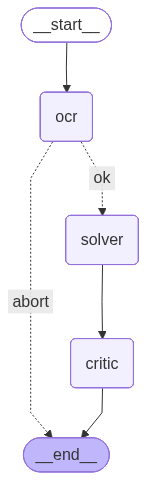

In [11]:
graph

In [12]:
from IPython.display import Image as IPImage

try:
    IPImage(graph.get_graph().draw_mermaid_png())
except Exception:
    print(graph.get_graph().draw_mermaid())

---
## Cell 7 — Helper: Build Initial State
All optional fields start as `None`. The new `units` field is also `None` until the parser fills it.

In [13]:
def make_initial_state(image_input) -> HWGraderState:
    return HWGraderState(
        image_input    = image_input,
        ocr_result     = None,
        parsed_problem = None,
        units          = None,    # ← NEW: filled by parser
        solver_result  = None,
        critic_result  = None,
        error          = None,
    )

---
## Demo A — OCR API Test

In [ ]:
import time, os, requests

TEST_IMAGE   = r"ocr_test_images/SFD_BMD.jpeg"
CHANDRA_API_URL    = "https://www.datalab.to/api/v1/convert"
POLL_INTERVAL_SECS = 2
MAX_POLL_ATTEMPTS  = 30

CHANDRA_API_KEY = os.environ.get("CHANDRA_API_KEY", "your-key-here")
print(f"API key loaded: {repr(CHANDRA_API_KEY)}")

t0      = time.time()
headers = {"X-API-Key": CHANDRA_API_KEY}

with open(TEST_IMAGE, "rb") as f:
    response = requests.post(
        CHANDRA_API_URL,
        headers=headers,
        files={"file": (os.path.basename(TEST_IMAGE), f, "image/jpeg")},
        data={"output_format": "markdown", "mode": "balanced"},
    )

print(f"Status code : {response.status_code}")
print(f"Response    : {response.text[:300]}")
response.raise_for_status()

job = response.json()
if not job.get("success"):
    raise RuntimeError(f"Submission failed: {job.get('error')}")

check_url = job["request_check_url"]
print(f"Job submitted. Polling {check_url}...")

markdown = ""
for attempt in range(MAX_POLL_ATTEMPTS):
    time.sleep(POLL_INTERVAL_SECS)
    result = requests.get(check_url, headers=headers).json()
    status = result.get("status", "")
    print(f"  Attempt {attempt+1}: {status}")

    if status == "complete":
        markdown = result.get("markdown", "")
        break
    elif status == "error":
        raise RuntimeError(f"API error: {result.get('error')}")
else:
    raise TimeoutError("Chandra API did not complete within timeout.")

elapsed = time.time() - t0
print(f"\nTime taken : {elapsed:.1f}s")
print(f"Total chars: {len(markdown)}")
print("\n" + "=" * 60)
print("  EXTRACTED MARKDOWN")
print("=" * 60)
print(markdown)

---
## Demo B — Full Pipeline Test

In [19]:
import glob, os, time

# ─── CONFIGURE INPUT ─────────────────────────────────────────────────────────

# Option A: Single image
# IMAGE_INPUTS = r"path/to/your/homework.jpg"

# Option B: Multiple pages
IMAGE_INPUTS = [r"ocr_test_images/substitution.jpeg"]

# Option C: All images in a folder
# IMAGE_INPUTS = sorted(glob.glob(r"path/to/homework_folder/*.jpg"))

# ─── VALIDATION ──────────────────────────────────────────────────────────────

inputs = [IMAGE_INPUTS] if isinstance(IMAGE_INPUTS, str) else list(IMAGE_INPUTS)
if not inputs:
    raise ValueError("IMAGE_INPUTS is empty.")

missing = [p for p in inputs if not os.path.exists(p)]
if missing:
    print("❌ Missing image(s):")
    for p in missing:
        print(f"   {p}")
    raise FileNotFoundError(f"{len(missing)} image(s) missing.")

print("=" * 65)
print("  FULL PIPELINE TEST")
print("=" * 65)
print(f"  Input image(s) : {len(inputs)}")
for i, p in enumerate(inputs, 1):
    size_kb = os.path.getsize(p) / 1024
    print(f"    [{i}] {os.path.basename(p)}  ({size_kb:.1f} KB)")
print()

# ─── RUN ─────────────────────────────────────────────────────────────────────

initial_state = make_initial_state(inputs if len(inputs) > 1 else inputs[0])
final_state   = initial_state.copy()
t_start       = time.time()

NODE_LABELS = {
    "ocr"   : "Node 1/3 — Chandra OCR",
    "solver": "Node 2/3 — Parser + Solver",
    "critic": "Node 3/3 — Critic",
}

for step in graph.stream(initial_state):
    node_name   = list(step.keys())[0]
    node_output = step[node_name]
    final_state.update(node_output)

    elapsed = time.time() - t_start
    label   = NODE_LABELS.get(node_name, node_name)
    print(f"\n✅  {label}  ({elapsed:.1f}s elapsed)")

    if node_name == "ocr":
        if final_state.get("error"):
            print(f"   ❌ OCR failed: {final_state['error']}")
            break
        ocr = final_state.get("ocr_result", {})
        print(f"   Pages: {ocr.get('page_count', 1)}")
        print(f"   Chars: {len(ocr.get('markdown', ''))}")
        print("   ── OCR Preview (400 chars) ──")
        print(ocr.get("markdown", "")[:400])

    elif node_name == "solver":
        if final_state.get("error"):
            print(f"   ❌ Solver failed: {final_state['error']}")
            break
        parsed = final_state.get("parsed_problem", {})
        units  = final_state.get("units", {})
        ptype  = parsed.get("problem_type", "unknown")
        print(f"   Problem type : {ptype}")
        print(f"   Units        : {units}")
        if ptype == "beam_reactions":
            print(f"   Span  : {parsed.get('span', '?')} {units.get('length', 'm')}")
            print(f"   Loads : {len(parsed.get('loads', []))}")
        elif ptype in ("graph_theory", "other"):
            sr = final_state.get("solver_result", {})
            if sr.get("execution_result"):
                print("   ── E2B Output ──")
                print(sr["execution_result"][:600])

    elif node_name == "critic":
        if final_state.get("error"):
            print(f"   ❌ Critic failed: {final_state['error']}")
            break

# ─── FINAL REPORT ────────────────────────────────────────────────────────────

total_time = time.time() - t_start
print(f"\n{'=' * 65}")
print(f"  PIPELINE COMPLETE — total time: {total_time:.1f}s")
print(f"{'=' * 65}")

if final_state.get("error"):
    print(f"\n❌ Pipeline error: {final_state['error']}")
elif final_state.get("critic_result"):
    print_critic_report(final_state["critic_result"])
else:
    print("No critic result — check node errors above.")

  FULL PIPELINE TEST
  Input image(s) : 1
    [1] substitution.jpeg  (145.3 KB)


[Node 1/3] OCR — Chandra hosted API...
   Page 1/1...
   Job submitted. Polling for result...
   Attempt 1: processing
   Attempt 2: processing
   Attempt 3: processing
   Attempt 4: processing
   Attempt 5: complete
OCR complete — 1 page(s), 1152 chars
-------------------------------------------------------


# Substitution method

$$T(n) = \begin{cases} \Theta(1) & \text{if } n=1 \\ 3T(n/2) + cn^2 & \text{otherwise} \end{cases}$$

$$T(n) = 3T(n/2) + cn^2 \quad \left| \begin{array}{l} T(n/2) = 3T(n/4) + cn^2(\frac{1}{4}) \\ T(n/4) = 3T(n/8) + cn^2(\frac{1}{16}) \end{array} \right.$$

$$= 3 \left[ 3T(n/4) + cn^2(\frac{1}{4}) \right] + cn^2$$

$$= 9T(n/4) + cn^2(\frac{3}{4}) + cn^2$$

$$= 9 \left[ 3T(n/8) + cn^2(\frac{1}{16}) \right] + cn^2(\frac{3}{4}) + cn^2$$

$$= 27T(n/8) + cn^2(\frac{3}{4})^2 + cn^2(\frac{3}{4}) + cn^2$$

$$= 3^3 T(n/2^3) + cn^2 \left( 1 + \frac{3}{4} + \left(\frac{3}{4}\right...
----

---
## Demo C — General Math ("Other" type) via Unified E2B

Test the `other` problem type by injecting simulated OCR.
Bypasses Node 1 (OCR) and exercises Node 2 (unified E2B solver) + Node 3 (Critic).

In [ ]:
# ─── Demo C: General Math (Other) via Unified E2B ────────────────────────────

SIMULATED_OCR_OTHER = """
Evaluate the definite integral:  integral from 0 to 2 of (3x^2 + 2x) dx

Solution:
Step 1: Find antiderivative
  F(x) = 3x^3 + x^2      (student forgot to divide 3x^2 by 3)

Step 2: Apply limits  [0, 2]
  F(2) = 3(2^3) + (2^2) = 24 + 4 = 28
  F(0) = 0
  Result = 28 - 0 = 28

Answer: 28
"""

# Inject into state (Demo B pattern — skips OCR node)
partial_state_f: HWGraderState = {
    "image_input"   : [],
    "ocr_result"    : OCRResult(markdown=SIMULATED_OCR_OTHER, raw_ocr=SIMULATED_OCR_OTHER, page_count=1).model_dump(),
    "parsed_problem": None,
    "units"         : None,
    "solver_result" : None,
    "critic_result" : None,
    "error"         : None,
}

# ── Run solver node directly ─────────────────────────────────────────────────
solver_out_f = node_solver(partial_state_f)
partial_state_f.update(solver_out_f)

if partial_state_f.get('error'):
    print(f"Solver error: {partial_state_f['error']}")
else:
    print("\n--- Solver done. Running critic... ---\n")
    critic_out_f = node_critic(partial_state_f)
    partial_state_f.update(critic_out_f)
    print_critic_report(partial_state_f.get('critic_result'))